# **Grammys Project**

# **Introduction**
*Michael Gallo and Nick Kent*

In this project, we work on real data from both websites owned by The Recording Academy, the non-profit organization behind the famous Grammy Awards. Ray Starck, the VP of Digital Strategy, decided to split the websites into grammy.com and recordingacademy.com to better serve the Recording Academy's various audience needs.

Now, we will examine the impact of splitting up the two websites, and analyze the data for a better understanding of trends and audience behavior on both sites.

**An Important Note:**
For the purposes of our analysis, the more time a user spends on the website, the better. Though the user may not *want* to spend more time on the website, their viewtime is important for advertisements and attention retention. And therefore, the more time a user spends on the site, the better it is for the company, who we are working for in this "scenario".

# **1. Setup**
In this section we prepare our environment: import packages, load all datasets, and define any helper functions we’ll use throughout the notebook.

### **1.1 Import Libraries**

In [1]:
# Import necessary libraries
import pandas as  pd
import numpy as np
import warnings
# Plotting 
import matplotlib.pyplot as plt
# Plotting events against graphs
import matplotlib.dates as mdates
# Statistical testing
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.proportion import proportions_ztest

### **1.2 Load Datasets**

In [2]:
# Load datasets from CSV files
full_df = pd.read_csv('datasets/grammy_live_web_analytics.csv')
rec_academy = pd.read_csv('datasets/ra_live_web_analytics.csv')

age_grammys = pd.read_csv('datasets/grammys_age_demographics.csv')
age_tra = pd.read_csv('datasets/tra_age_demographics.csv')

events = pd.read_csv('datasets/grammy_awards_key_dates_2017_2023.csv')

### **1.3 Helper Functions & Global Settings**

In [3]:
# Set Global settings, define helper functions

# Define a consistent color map and labels for the sites
SITE_LABELS = ['combined_site (Before Split)', 'grammys (After Split)', 'rec_academy (After Split)']
SITE_COLORS = ['#38761d', '#980000', '#4a86e8']
# Consistent way to loop up colors by label
color_lookup = dict(zip(SITE_LABELS, SITE_COLORS))

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Helper function for calculating bounce rate later in the project.
def bounce_rate(dataframe):
    '''
    Calculates the bounce rate for visitors on the website.
    input: dataframe with bounced_sessions and sessions columns
    output: numeric value from bounce rate
    '''
    sum_bounced = dataframe['bounced_sessions'].sum()
    sum_sessions = dataframe['sessions'].sum()
    
    return 100 * sum_bounced / sum_sessions


# Helper function for plotting timelines
def plot_timeline(sites, site_labels, site_colors, feature):
    for site, label, color in zip(sites, site_labels, site_colors):
        plt.plot(
            site['date'],
            site[feature],
            label=label,
            color=color,
            linewidth=2
        )

# **2. Data Overview**
Here we describe each table, its time span, and primary variables (sessions, bounce rate, session duration, demographics, etc.).
### **2.1 Dataset Descriptions**
We start with two files, `grammys_live_web_analytics.csv` and `ra_live_web_analytics.csv`, importing the grammys site as `full_df`, and the recording academy site data as `rec_academy`. 

When The Recording Academy decided to split their website into two domains on `2022-02-01`, grammy.com and recordingacademy.com, the data capture for grammy.com was not affected. So the `full_df` variable needs to be split separately into two dataframes. This split is completed later in the code!!

In [4]:
full_df.info()
full_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2342 entries, 0 to 2341
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   date                       2342 non-null   object
 1   visitors                   2342 non-null   int64 
 2   pageviews                  2342 non-null   int64 
 3   sessions                   2342 non-null   int64 
 4   bounced_sessions           2342 non-null   int64 
 5   avg_session_duration_secs  2342 non-null   int64 
 6   awards_week                2342 non-null   int64 
 7   awards_night               2342 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 146.5+ KB


,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
0,2017-01-01,9611,21407,10196,6490,86,0,0
1,2017-01-02,10752,25658,11350,7055,100,0,0
2,2017-01-03,11425,27062,12215,7569,92,0,0
3,2017-01-04,13098,29189,13852,8929,90,0,0
4,2017-01-05,12234,28288,12990,8105,95,0,0
5,2017-01-06,11461,28022,12309,7500,95,0,0
6,2017-01-07,11183,27491,11993,7287,94,0,0
7,2017-01-08,16265,38529,17361,10587,84,0,0
8,2017-01-09,17852,40698,18914,11697,87,0,0
9,2017-01-10,14211,33218,15124,9270,96,0,0


In [5]:
rec_academy.info()
rec_academy.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   date                       485 non-null    object
 1   visitors                   485 non-null    int64 
 2   pageviews                  485 non-null    int64 
 3   sessions                   485 non-null    int64 
 4   bounced_sessions           485 non-null    int64 
 5   avg_session_duration_secs  485 non-null    int64 
 6   awards_week                485 non-null    int64 
 7   awards_night               485 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 30.4+ KB


,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
0,2022-02-01,928,2856,1092,591,148,0,0
1,2022-02-02,1329,3233,1490,923,90,0,0
2,2022-02-03,1138,3340,1322,754,127,0,0
3,2022-02-04,811,2552,963,534,142,0,0
4,2022-02-05,541,1530,602,326,111,0,0
5,2022-02-06,536,1669,610,339,147,0,0
6,2022-02-07,921,3512,1117,567,198,0,0
7,2022-02-08,1106,3662,1296,661,163,0,0
8,2022-02-09,1181,4209,1382,725,150,0,0
9,2022-02-10,1134,3473,1341,727,140,0,0


Furthermore, our age/demographics datasets are fundamentally explored below.

In [6]:
age_grammys.info()
age_grammys.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age_group     6 non-null      object 
 1   pct_visitors  6 non-null      float64
dtypes: float64(1), object(1)
memory usage: 228.0+ bytes


,age_group,pct_visitors
0,18-24,27.37
1,25-34,24.13
2,35-44,18.72
3,45-54,13.57
4,55-64,9.82
5,65+,6.39


In [7]:
age_tra.info()
age_tra.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age_group     6 non-null      object 
 1   pct_visitors  6 non-null      float64
dtypes: float64(1), object(1)
memory usage: 228.0+ bytes


,age_group,pct_visitors
0,18-24,27.12
1,25-34,26.16
2,35-44,19.55
3,45-54,13.82
4,55-64,8.24
5,65+,5.12


And lastly, we preview our custom dataset created based on the events relevant to the Recording Academy and the Grammy awards:

In [8]:
events.info()
events.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      7 non-null      int64 
 1   Eligibility Period Begin  7 non-null      object
 2   Eligibility Period End    7 non-null      object
 3   Entry Period Begin        1 non-null      object
 4   Entry Period End          1 non-null      object
 5   First Round Voting Begin  2 non-null      object
 6   First Round Voting End    2 non-null      object
 7   Nominations Announcement  7 non-null      object
 8   Final Round Voting Begin  2 non-null      object
 9   Final Round Voting End    2 non-null      object
 10  Telecast Date             7 non-null      object
dtypes: int64(1), object(10)
memory usage: 748.0+ bytes


,Year,Eligibility Period Begin,Eligibility Period End,Entry Period Begin,Entry Period End,First Round Voting Begin,First Round Voting End,Nominations Announcement,Final Round Voting Begin,Final Round Voting End,Telecast Date
0,2023,2021-08-01,2022-09-30,2022-07-18,2022-08-31,2022-08-13,2022-08-23,2022-11-15,2022-10-14,2023-01-04,2023-02-05
1,2022,2020-09-01,2021-09-30,NaN,NaN,2021-08-22,2021-09-05,2021-11-23,2021-12-06,2022-01-05,2022-04-03
2,2021,2019-08-01,2020-08-31,NaN,NaN,NaN,NaN,2020-11-24,NaN,NaN,2021-03-14
3,2020,2018-08-01,2019-08-31,NaN,NaN,NaN,NaN,2019-11-20,NaN,NaN,2020-01-26
4,2019,2017-08-01,2018-09-30,NaN,NaN,NaN,NaN,2018-12-07,NaN,NaN,2019-02-10
5,2018,2016-08-01,2017-09-30,NaN,NaN,NaN,NaN,2017-11-28,NaN,NaN,2018-01-28
6,2017,2015-08-01,2016-09-30,NaN,NaN,NaN,NaN,2016-12-06,NaN,NaN,2017-02-12


### **2.2 Data Dictionaries**

##### **2.2.1 `full_df` and `rec_academy` Dataframes**

The dataframes for `full_df` and `rec_academy` contain the following information:
- **date** - The date the data was confirmed. It is in `yyyy-mm-dd` format.
- **visitors** - The number of users who went on the website on that day.
- **pageviews** - The number of pages that all users viewed on the website.
- **sessions** - The total number of sessions on the website. A session is a group of user interactions with your website that take place within a given time frame. For example a single session can contain multiple page views, events, social interactions.
- **bounced_sessions** - The total number of bounced sessions on the website. A bounced session is when a visitor comes to the website and does not interact with any pages / links and leaves.
- **avg_session_duration_secs** - The average length for all session durations for all users that came to the website that day.
- **awards_week** - A binary flag if the dates align with marketing campaigns before and after the Grammys award ceremony was held. This is the big marketing push to get as many eyeballs watching the event.
- **awards_night** - The actual night that Grammy Awards event was held.

##### **2.2.2 `age_grammys` and `age_tra` Dataframes**

The demographics dataframes for `age_grammys` and `age_tra` contain the following information:

- **age_group** – The visitor’s age bracket (e.g. “18–24”, “25–34”, …).  
- **pct_visitors** – Percentage of total site visitors in that age group on a given day.

##### **2.2.3 `events` Dataframe**

Here’s a quick dictionary for each column/event in the Grammy events timeline (each of which have an associated date in the format YYYY-MM-DD):

**Year**

- Award ceremony edition (e.g. 2023 refers to the 65th Grammys held in early 2023).

**Eligibility Period Begin / End**

- The release‐date window during which music must have been published to qualify for that year’s awards.

**Entry Period Begin / End**

- When content‐owners (labels, artists) may submit eligible recordings into consideration.

**First Round Voting Begin / End**

- The span during which Recording Academy voting members cast their nomination ballots.

**Nominations Announcement**

- The single date on which the final list of nominees in each category is publicly revealed.

**Final Round Voting Begin / End**

- When voting members cast their winner‐selection ballots among that year’s nominees.

**Telecast Date**

- The live broadcast date of the Awards Ceremony itself, when winners are announced on stage.

# **3. Data Cleaning & Preprocessing**
Standardize timestamps, handle missing values, merge competitor and Grammys data, and carve out pre‑ and post‑split periods.

### **3.1 Timestamp Conversion & Filtering**

In [9]:
# ensure timestamp is datetime, filter by date range
full_df["date"] = pd.to_datetime(full_df["date"], format='%Y-%m-%d')
full_df = full_df.sort_values('date')

rec_academy["date"] = pd.to_datetime(rec_academy["date"], format='%Y-%m-%d')
rec_academy = rec_academy.sort_values('date')

### **3.2 Function to Overlay Grammy Events onto Plots**

The below function converts our events dataset into a format which can be plotted onto any graph with dates on the x-axis. The function only plots events that are visible on the x-axis of the plot passed into the function.

In [10]:
# Define function to overlay events on a plot

# Parse events from dataset
date_cols = [
    'Eligibility Period Begin','Eligibility Period End',
    'Entry Period Begin','Entry Period End',
    'First Round Voting Begin','First Round Voting End',
    'Final Round Voting Begin','Final Round Voting End',
    'Nominations Announcement','Telecast Date'
]
for col in date_cols:
    events[col] = pd.to_datetime(events[col], format='%Y-%m-%d', errors='coerce')

def overlay_grammy_events(ax, events_df, threshold_days=100, event_color='black'):
    """
    Overlays Grammy event spans and lines onto the provided Axes.
    Only draws events within the current x-axis view.
    """
    # Compute visible x-limits as naive datetimes
    x0, x1 = ax.get_xlim()
    start_visible = mdates.num2date(x0).replace(tzinfo=None)
    end_visible = mdates.num2date(x1).replace(tzinfo=None)

    ymin, ymax = ax.get_ylim()
    alpha = 0.2

    spans = [
        ('Eligibility Period Begin','Eligibility Period End','C0','Elig',0.88),
        ('Entry Period Begin','Entry Period End','C1','Entry',0.60),
        ('First Round Voting Begin','First Round Voting End','C2','1stVote',0.78),
        ('Final Round Voting Begin','Final Round Voting End','C3','FinalVote',0.78),
    ]
    singles = [
        ('Nominations Announcement','C4','Noms',0.75),
        ('Telecast Date','C5','Telecast',0.70),
    ]

    for _, row in events_df.iterrows():
        year = int(row['Year'])

        # Multi-day spans
        for start_col, end_col, color, label, ypos in spans:
            b, e = row[start_col], row[end_col]
            if pd.notna(b) and pd.notna(e):
                # Convert event datetimes to naive for comparison
                b_naive = b.to_pydatetime().replace(tzinfo=None)
                e_naive = e.to_pydatetime().replace(tzinfo=None)
                if e_naive < start_visible or b_naive > end_visible:
                    continue
                ax.axvspan(b_naive, e_naive, color=color, alpha=alpha)
                span_days = (e_naive - b_naive).days
                rot, ha, va = (90, 'center', 'bottom') if span_days <= threshold_days else (0, 'left', 'center')
                mid = b_naive + (e_naive - b_naive) / 2
                ax.text(mid, ymax * ypos, f"{label} {year}", rotation=rot, ha=ha, va=va, fontsize=8, color=event_color, fontweight='bold')

        # Single-day events
        for col, color, label, ypos in singles:
            d = row[col]
            if pd.notna(d):
                d_naive = d.to_pydatetime().replace(tzinfo=None)
                if d_naive < start_visible or d_naive > end_visible:
                    continue
                ax.axvline(d_naive, color=color, linestyle='--', alpha=0.7)
                ax.text(d_naive, ymax * ypos, f"{label} {year}", rotation=90, va='top', ha='right', fontsize=8, color=event_color, fontweight='bold')

    ax.ticklabel_format(style='plain', axis='y', useOffset=False)

    # Format x-axis
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis_date()
    ax.figure.autofmt_xdate()

### **3.3 Handling Missing or Anomalous Records**
Our further analyses show no missing records. The N/A columns in events are handled by our events overlay function in section 3.2.

In [11]:
# Print the number of missing values in each dataframe, results in 0
missing_values = 0
for df in [full_df, rec_academy]:
    missing_values += df.isna().sum().sum()
    # For debugging which dataframe has missing values
    # print(df.isna().sum())
print(f"Total missing values: {missing_values}")

Total missing values: 0


### **3.4 Defining Pre‑Split vs Post‑Split Cohorts**
As previously discussed, we split website based on the date to accurately represent the split vs combined sites.

In [12]:
# Split the data to separate the full_df into two new dataframes.
# One for before the switch of the websites and one for after
combined_site = full_df[full_df['date'] < '2022-02-01']
grammys = full_df[full_df['date'] >= '2022-02-01']

# .copy() prevents pandas from printing a scary-looking warning message
combined_site = combined_site.copy()
grammys = grammys.copy()

### **3.5 Combining DataFrames into Custom Format!**
Here we add each site to a list, which we can iterate through in future work.

In [13]:
# Assign sites to a list...
sites = [combined_site, rec_academy, grammys]
# Refers back to the labels SITE_LABELS and SITE_COLORS as previously defined

### **3.6 Custom Column Additions!**

First, we define the site in each df's records, for later use in combining sites.

In [14]:
# Label the sites for clarity in the plots
combined_site['site'] = SITE_LABELS[0]
rec_academy['site'] = SITE_LABELS[1]
grammys['site'] = SITE_LABELS[2]

Next, to better capture user “stickiness” and loyalty, we compute four new engagement metrics on each site:

- **`pages_per_session`**: average number of pages viewed per session (`pageviews / sessions`)
- **`bounce_rate`**: percentage of sessions with no interaction (`bounced_sessions / sessions * 100`)
- **`engagement_rate`**: inverse of bounce rate, i.e. percent of sessions with at least one interaction (`100 - bounce_rate`)
- **`sessions_per_visitor`**: proxy for return visits (`sessions / visitors`)

In [15]:
# Calculate the number of sessions, pageviews, and visitors for each site

# pages per session: how many pages on average each session views
for site in sites:
    site['pages_per_session'] = site['pageviews'] / site['sessions']

# bounce rate: % of sessions with no interaction
for site in sites:
    site['bounce_rate'] = site['bounced_sessions'] / site['sessions'] * 100

# engagement rate: inverse of bounce, i.e., % of sessions with interaction
for site in sites:
    site['engagement_rate'] = 100 - site['bounce_rate']

# sessions per visitor: proxy for return visits
for site in sites:
    site['sessions_per_visitor'] = site['sessions'] / site['visitors']

Finally, we merge our two age‑demographics tables into one for easier comparison

In [16]:
# Join the two age demographics datasets

# create website column for easier demography analysis
age_grammys['website'] = 'Grammys'
age_tra['website'] = 'Recording Academy'

# use pd.concat to join the two demography datasets
age_df = pd.concat([age_grammys, age_tra])
age_df

,age_group,pct_visitors,website
0,18-24,27.37,Grammys
1,25-34,24.13,Grammys
2,35-44,18.72,Grammys
3,45-54,13.57,Grammys
4,55-64,9.82,Grammys
5,65+,6.39,Grammys
0,18-24,27.12,Recording Academy
1,25-34,26.16,Recording Academy
2,35-44,19.55,Recording Academy
3,45-54,13.82,Recording Academy


# **4. Visual Analysis (EDA via Plots Only)**

### **4.1 Age-Group Demographics**

The bar chart below shows that they receive a similar proportion of visitors per age group across both websites. However, people over the age of ~55 will tend to visit the Grammys site more often than the Recording Academy site.

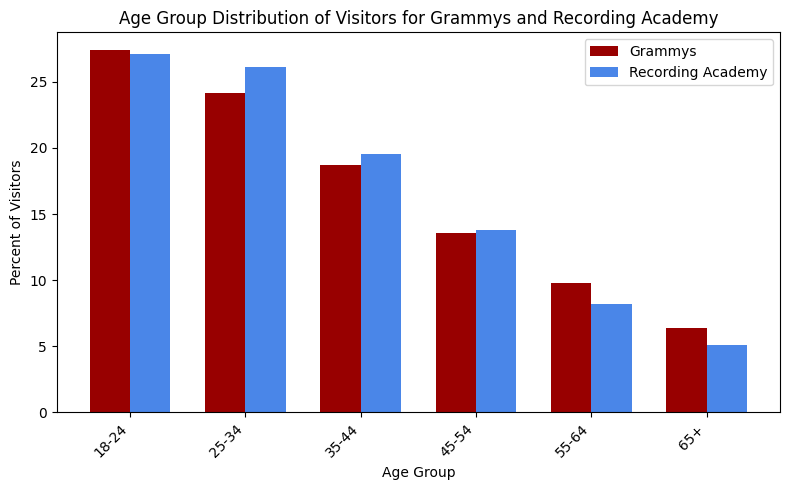

In [17]:
# Plot the age demographics of the two sites in a bar plot...

# Pivot the DataFrame so each site is its own column
pivot = age_df.pivot(index='age_group', columns='website', values='pct_visitors')

# Set up the x locations & bar width
age_groups = pivot.index.tolist()
x = np.arange(len(age_groups))
width = 0.35

# Create the bars
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, pivot['Grammys'], width, label='Grammys', color=SITE_COLORS[1])
ax.bar(x + width/2, pivot['Recording Academy'], width, label='Recording Academy', color=SITE_COLORS[2])

# Labels, ticks & legend
ax.set_xticks(x)
ax.set_xticklabels(age_groups, rotation=45, ha='right')
ax.set_xlabel('Age Group')
ax.set_ylabel('Percent of Visitors')
ax.set_title('Age Group Distribution of Visitors for Grammys and Recording Academy')
ax.legend()

plt.tight_layout()
plt.show()

### **4.2 Daily Metrics––Pre vs Post Split**

**Bounce Rate (lower is better)** measures the percentage of visitors who leave after viewing only one page.

- **Pre‑split (combined site):** 41.58 %  
- **Post‑split (weighted combined):** 39.86 % (↓ 1.72 pp)  
- **Grammys.com:** 40.16 %  
- **RecordingAcademy.com:** 33.67 %  

_The split produced a modest overall reduction in bounce rate, with RecordingAcademy.com seeing the greatest improvement._

---

**Average Session Duration (higher is better)** is the average length of a user’s visit in seconds.

- **Pre‑split:** 134.80 s  
- **Post‑split (weighted combined):** 120.35 s (↓ 14.45 s)  
- **Grammys.com:** 120.65 s  
- **RecordingAcademy.com:** 114.15 s  

_Contrary to our initial unweighted summary, true session‑weighted duration fell substantially after the split on both domains._

---

**Pages Per Session (higher is better)** captures how many pages a user views in a single session—a proxy for depth of engagement.

- **Pre‑split:** 1.86  
- **Post‑split (weighted combined):** 2.28 (↑ 0.42)  
- **Grammys.com:** 2.25  
- **RecordingAcademy.com:** 2.78  
> **Note:** pages per session is influenced by site layout and navigation design, but higher values would generally drive more ad impressions and deeper engagement.

---

**Summary:**  
Splitting the domains led to a clear uptick in pages per session and a modest drop in bounce rate, showing possible deeper engagement. However, average session duration declined when weighted by actual session counts—largely because grammys.com, which accounts for the majority of traffic, saw a notable decrease in time per visit. RecordingAcademy.com excels in bounce rate and depth (pages per session), while Grammys.com improved depth but lost some session time compared to the pre‑split combined site. Overall, the domain split sharpened user focus and increased browsing depth, even as individual visit lengths shortened.  

In [18]:
# Compute and print metrics for pre‑split, separate post‑split sites, and weighted post‑split combined

# --- Pre‑split (combined_site) ---
ctrl_sess   = combined_site['sessions'].sum()
ctrl_bounce = combined_site['bounced_sessions'].sum()
ctrl_pv     = combined_site['pageviews'].sum()
ctrl_dur    = (combined_site['avg_session_duration_secs'] * combined_site['sessions']).sum() / ctrl_sess
ctrl_br     = ctrl_bounce  / ctrl_sess * 100
ctrl_pps    = ctrl_pv      / ctrl_sess

# --- Post‑split Grammys.com only ---
g_sess   = grammys['sessions'].sum()
g_bounce = grammys['bounced_sessions'].sum()
g_pv     = grammys['pageviews'].sum()
g_dur    = (grammys['avg_session_duration_secs'] * grammys['sessions']).sum() / g_sess
g_br     = g_bounce  / g_sess * 100
g_pps    = g_pv      / g_sess

# --- Post‑split RecordingAcademy.com only ---
ra_sess   = rec_academy['sessions'].sum()
ra_bounce = rec_academy['bounced_sessions'].sum()
ra_pv     = rec_academy['pageviews'].sum()
ra_dur    = (rec_academy['avg_session_duration_secs'] * rec_academy['sessions']).sum() / ra_sess
ra_br     = ra_bounce  / ra_sess * 100
ra_pps    = ra_pv      / ra_sess

# --- Post‑split weighted combined (Grammys + RA) ---
post = (
    grammys[['date','sessions','bounced_sessions','avg_session_duration_secs','pageviews']]
    .merge(
        rec_academy[['date','sessions','bounced_sessions','avg_session_duration_secs','pageviews']],
        on='date', suffixes=('_G','_RA')
    )
)
post['sessions']         = post['sessions_G'] + post['sessions_RA']
post['bounced_sessions'] = post['bounced_sessions_G'] + post['bounced_sessions_RA']
post['pageviews']        = post['pageviews_G']       + post['pageviews_RA']
post['avg_session_duration_secs'] = (
      post['avg_session_duration_secs_G'] * post['sessions_G']
    + post['avg_session_duration_secs_RA'] * post['sessions_RA']
) / post['sessions']
post_sess = post['sessions'].sum()
post_br   = post['bounced_sessions'].sum() / post_sess * 100
post_dur  = (post['avg_session_duration_secs'] * post['sessions']).sum() / post_sess
post_pps  = post['pageviews'].sum() / post_sess

# --- Output ---
print("=== Pre‑Split (Combined Site) ===")
print(f"Bounce Rate:          {ctrl_br:.2f}%")
print(f"Avg Session Duration: {ctrl_dur:.2f}s")
print(f"Pages Per Session:    {ctrl_pps:.2f}\n")

print("=== Post‑Split Weighted Combined ===")
print(f"Bounce Rate:          {post_br:.2f}%")
print(f"Avg Session Duration: {post_dur:.2f}s")
print(f"Pages Per Session:    {post_pps:.2f}\n")

print("=== Post‑Split Grammys.com ===")
print(f"Bounce Rate:          {g_br:.2f}%")
print(f"Avg Session Duration: {g_dur:.2f}s")
print(f"Pages Per Session:    {g_pps:.2f}\n")

print("=== Post‑Split RecordingAcademy.com ===")
print(f"Bounce Rate:          {ra_br:.2f}%")
print(f"Avg Session Duration: {ra_dur:.2f}s")
print(f"Pages Per Session:    {ra_pps:.2f}")

=== Pre‑Split (Combined Site) ===
Bounce Rate:          41.58%
Avg Session Duration: 134.80s
Pages Per Session:    1.86

=== Post‑Split Weighted Combined ===
Bounce Rate:          39.86%
Avg Session Duration: 120.35s
Pages Per Session:    2.28

=== Post‑Split Grammys.com ===
Bounce Rate:          40.16%
Avg Session Duration: 120.65s
Pages Per Session:    2.25

=== Post‑Split RecordingAcademy.com ===
Bounce Rate:          33.67%
Avg Session Duration: 114.15s
Pages Per Session:    2.78


### **4.3 Awards Night (Telecast) VS Regular Days**
In investigating what an "average" day looks like when the awards show is being hosted versus the other 364 days out of the year, we find that the site traffic explodes, with roughly 43x more users on the website for a ceremony day than there are on a regular day:

In [19]:
full_df.groupby('awards_night').agg({'visitors':'mean'})

,visitors
awards_night,
0,32388.28
1,1389590.23


### **4.4 Plotting Events Against Site Visitors**

As expected, the number of visitors boosts every year around November, when the nominees are announced, and sometime Q1 when the winners are announced. At first glance, it seems that the visitors come to the site solely to find out who was announced or who won for Grammy nominations.

Furthermore, there are spikes in traffic near the beginning and end of the Final Round voting, which makes sense, as users would cast their votes on the voting portal live on RecordingAcademy.org in this time period. Understandably, this trend is not reflected in the Grammys visitors.

But overall, the number of visitors does tend to remain stable aside from these events. Helpfully, the major spikes in visitors line up exactly with related Grammys/Recording Academy events.

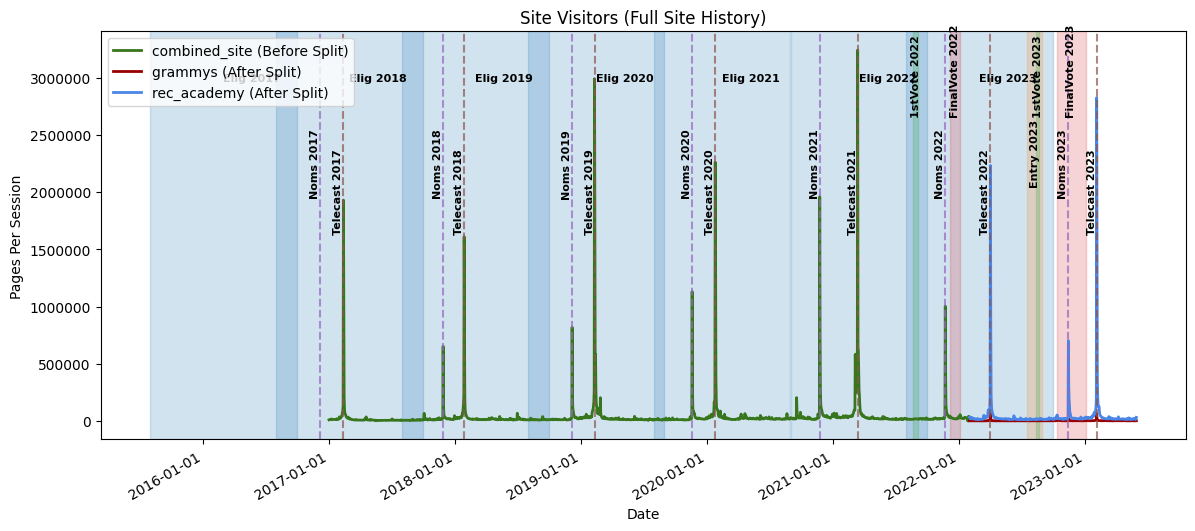

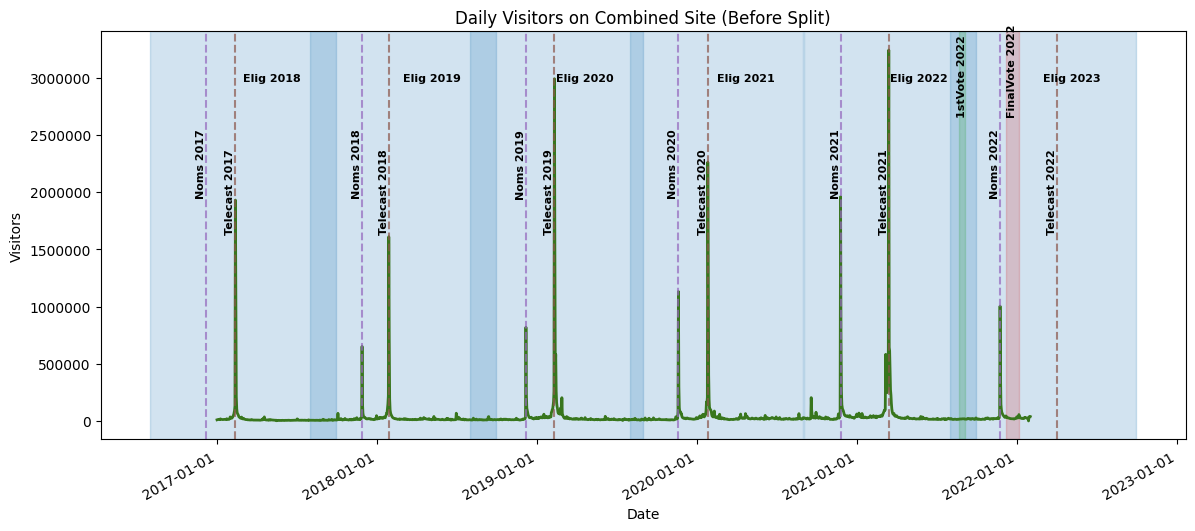

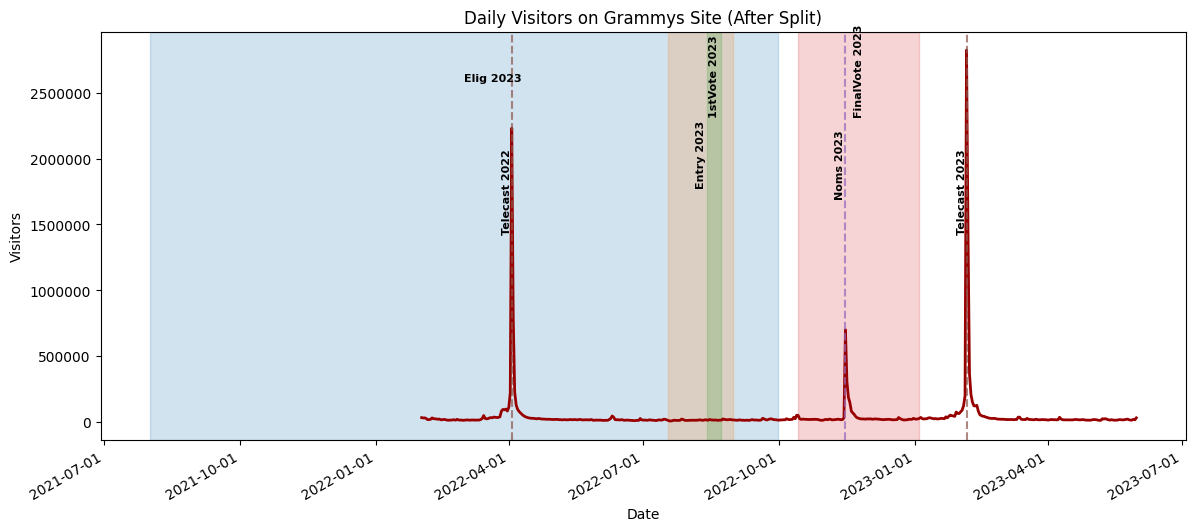

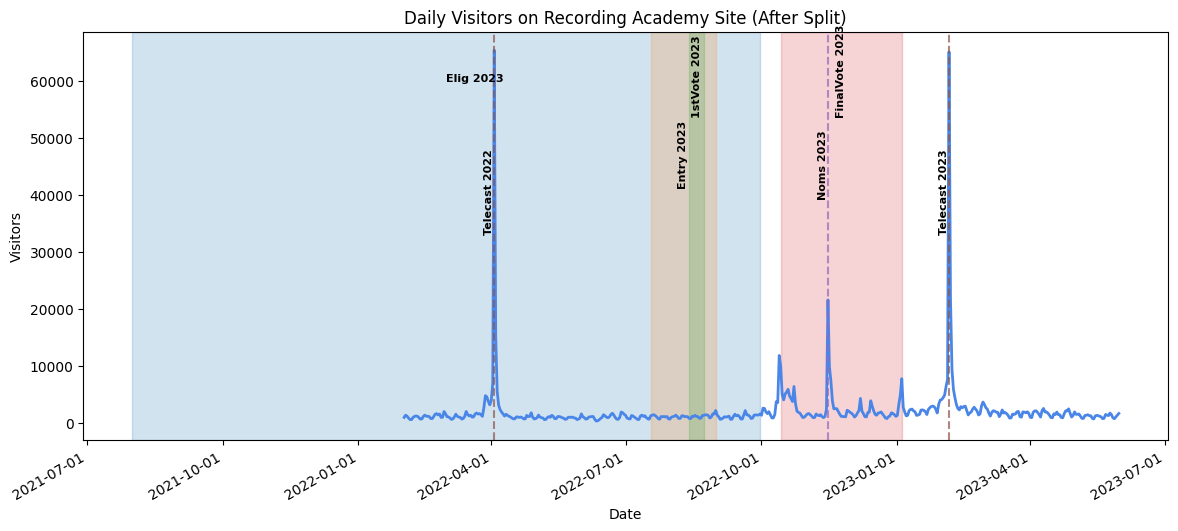

In [20]:
# Plot a line chart of the visitors on each site.

# Full Site History
full_hist_df = pd.concat([combined_site, grammys, rec_academy], ignore_index=True)
fig, ax = plt.subplots(figsize=(14,6))
for site_label, group in full_hist_df.groupby('site'):
    ax.plot(
        group['date'],
        group['visitors'],
        linewidth=2,
        label=site_label,
        color=color_lookup[site_label]
    )
overlay_grammy_events(ax, events)
ax.set_title('Site Visitors (Full Site History)')
ax.set_xlabel('Date')
ax.set_ylabel('Pages Per Session')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(14,6))
ax.plot(combined_site['date'], combined_site['visitors'], label='Visitors', linewidth=2, color=SITE_COLORS[0])
overlay_grammy_events(ax, events)
plt.title('Daily Visitors on Combined Site (Before Split)')
plt.xlabel('Date')
plt.ylabel('Visitors')
plt.show()

fig, ax = plt.subplots(figsize=(14,6))
ax.plot(grammys['date'], grammys['visitors'], label='Visitors', linewidth=2, color=SITE_COLORS[1])
overlay_grammy_events(ax, events)
plt.title('Daily Visitors on Grammys Site (After Split)')
plt.xlabel('Date')
plt.ylabel('Visitors')
plt.show()

fig, ax = plt.subplots(figsize=(14,6))
ax.plot(rec_academy['date'], rec_academy['visitors'], label='Visitors', linewidth=2, color=SITE_COLORS[2])
overlay_grammy_events(ax, events)
plt.title('Daily Visitors on Recording Academy Site (After Split)')
plt.xlabel('Date')
plt.ylabel('Visitors')
plt.show()

### **4.5 Plotting Events Against Pages Per Session**

### **The June 9, 2022 Spike...**

On **June 9, 2022** RecordingAcademy.com’s composite index jumps sharply—corresponding to rule‐change announcements for the 2023 Grammys. As **Billboard** reports, 

> “The Recording Academy has announced five new GRAMMY Awards categories to be awarded at the 2023 GRAMMYs, including Songwriter Of The Year (Non-Classical) and Best Score Soundtrack For Video Games And Other Interactive Media categories.”  [(Source)](https://grammy.com/news/2023-grammys-new-categories-songwriter-year-best-video-game-soundtrack-social-impact-special-merit-award-65th-grammy-awards?utm_source=chatgpt.com)  

That spike appears *only* on RecordingAcademy.com and *not* on Grammys.com, which suggests that rule‐change news is bringing a professional or industry‐focused audience to the Academy’s site.  

The split websites are succeeding in targeted marketing-fans go to Grammys.com for event coverage, and creators/members go to RecordingAcademy.com for policy and membership updates.

### **The First‑Round Voting Plateau (Aug 2022–Apr 2023)**

- First‑Round Voting, as described in section 2.2.3, ran **Aug 13–23, 2022**, and Final‑Round Voting ran from **Oct 14 2022–Jan 4 2023**.  
- Engagement on RecordingAcademy.com boosted massively during these windows and then held at an elevated plateau for over ***seven months***, through **April 2023**.  

This sustained plateau of engagement implies a successful, prolonged campaign, (likely through member emails and portal reminders), rather than discrete one‑day peaks. After April 2023, engagement naturally receded, as marketing generally pauses in the off‑cycle until the summer’s next entry period. Research of related events showed no other significant results that might indicate a separate reason for said drop-off.

### **Other Various Spikes**

All other spikes in pages per session can be attributed to one-off policy changes and/or updates to rules and regulations concerning the Grammy awards, given our research on the topic.

### **Main Takeaways**

The number of pages per person *does*, however, clearly increase when viewed in the context of the entire site's history...

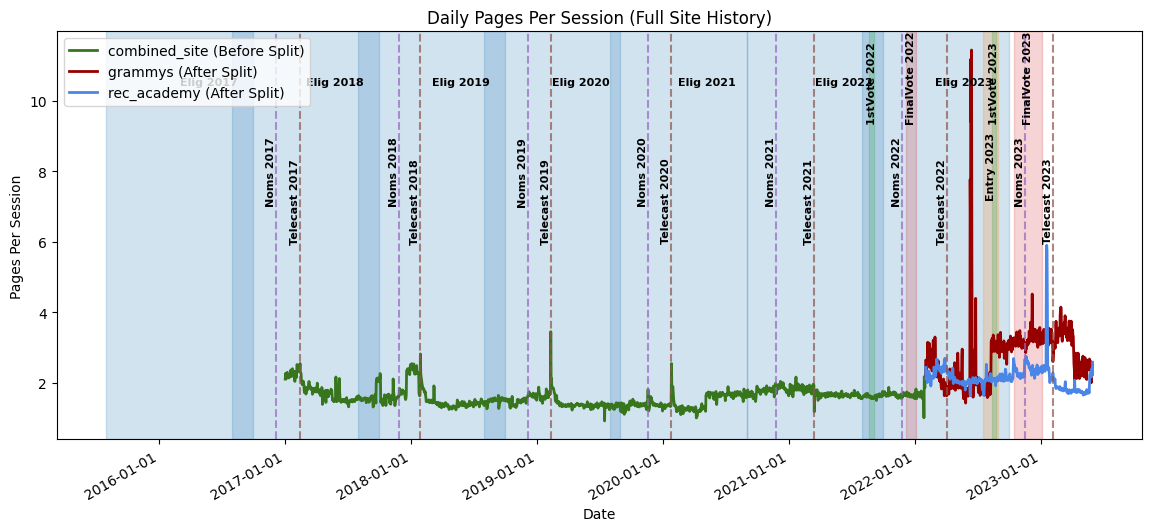

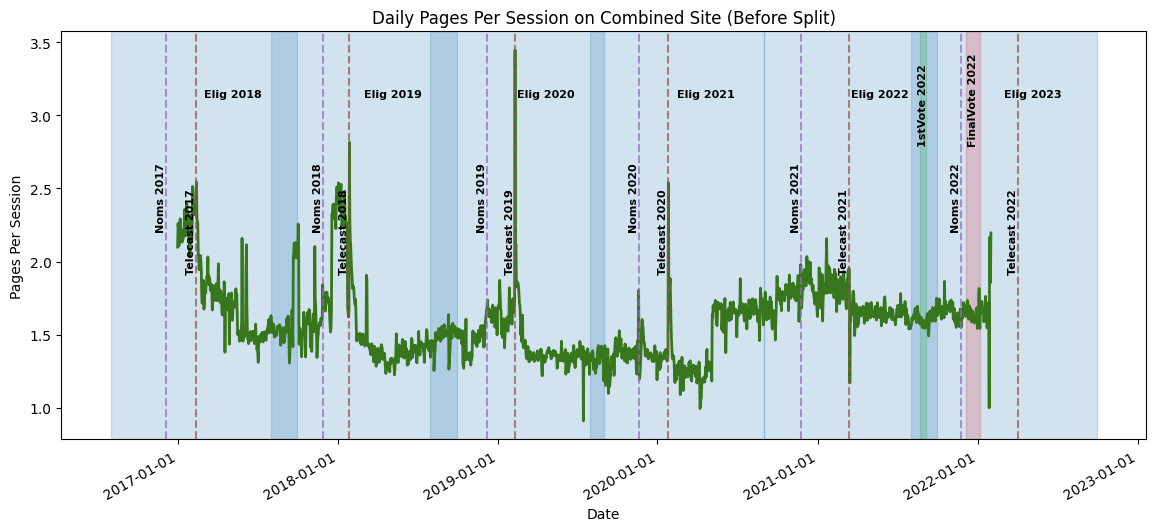

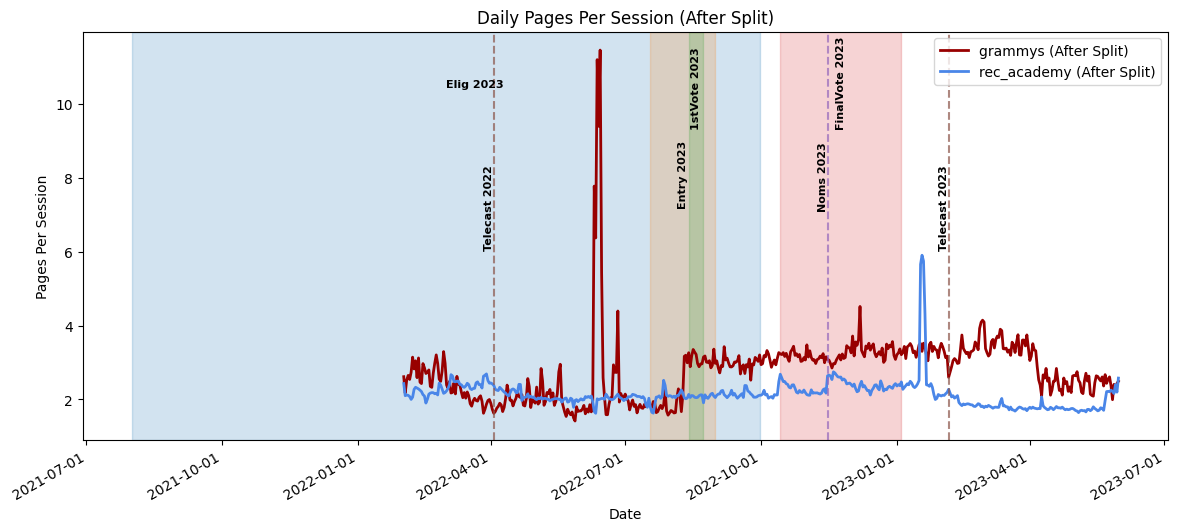

In [21]:
# Plot the Pages Per Session Pre and Post Split against the Grammy Events

# Full Site History
full_hist_df = pd.concat([combined_site, grammys, rec_academy], ignore_index=True)
fig, ax = plt.subplots(figsize=(14,6))
for site_label, group in full_hist_df.groupby('site'):
    ax.plot(
        group['date'],
        group['pages_per_session'],
        linewidth=2,
        label=site_label,
        color=color_lookup[site_label]
    )
overlay_grammy_events(ax, events)
ax.set_title('Daily Pages Per Session (Full Site History)')
ax.set_xlabel('Date')
ax.set_ylabel('Pages Per Session')
ax.legend()
plt.show()

# Before Split
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(combined_site['date'], combined_site['pages_per_session'], linewidth=2, color=SITE_COLORS[0])
overlay_grammy_events(ax, events)
plt.title('Daily Pages Per Session on Combined Site (Before Split)')
plt.xlabel('Date')
plt.ylabel('Pages Per Session')
plt.show()

# Combined grammys and rec_academy After Split
post_split_df = pd.concat([grammys, rec_academy], ignore_index=True)

fig, ax = plt.subplots(figsize=(14,6))
for site_label, group in post_split_df.groupby('site'):
    ax.plot(
        group['date'],
        group['pages_per_session'],
        linewidth=2,
        label=site_label,
        color=color_lookup[site_label]
    )
overlay_grammy_events(ax, events)
ax.set_title('Daily Pages Per Session (After Split)')
ax.set_xlabel('Date')
ax.set_ylabel('Pages Per Session')
ax.legend()
plt.show()

### **4.6 Pages Per Session -- Deeper Dive**

Noting the `pages_per_session` when the websites were combined versus after they were split, there appeared to be less stability in the combined sites, whereas the separated sites tend to hold much more stability, with the sum of both sites' pages per session combining to be larger than they were separately. This suggests that users interact with the sites for longer when the sites are better specialized to their interests. 

As for the average session duration, we see that users tend to stay longer on the Recording Academy site, which makes sense. If a user came to the site, they are likely looking deeper into the music industry. However, if one is visiting the Grammy's site, it is more likely to keep themselves updated with the Grammy's news, and they will likely 'bounce' after receiving the information that they need. Furthermore, the bounce rate confirms this finding as well, with users 'bouncing' less on the Recording Academy site. Overall, we see a lower bounce rate, which infers that the site's splitting was indeed for the best.

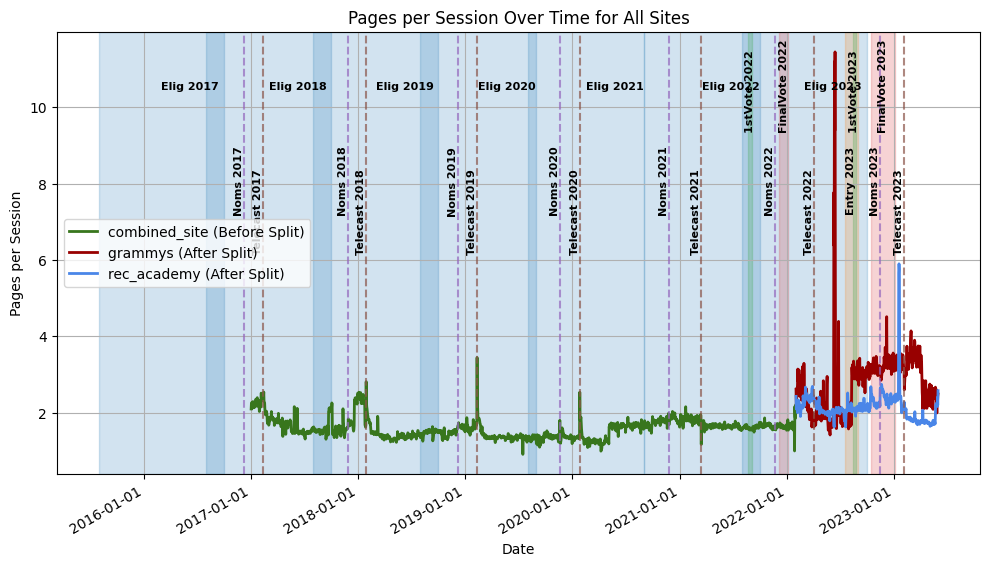

In [22]:
# Plot pages per session for all sites
plt.figure(figsize=(10, 6))
plot_timeline(sites, SITE_LABELS, SITE_COLORS, 'pages_per_session')
plt.title("Pages per Session Over Time for All Sites")
plt.xlabel("Date")
plt.ylabel("Pages per Session")
plt.legend()
plt.grid(True)
plt.tight_layout()
overlay_grammy_events(plt.gca(), events)

# **5. Methodology**

*We define our control (pre‑split) and treatment (post‑split combined domains) cohorts, state hypotheses, select test statistics, and run a power analysis.*

### **5.1 Cohort Definitions & Metric Aggregation**

##### **5.1.1 Control: Pre‑Split (combined_site)**

In [23]:
# Clean pre-split data for testing

# Pre‑split data
control = combined_site.copy()

# Derived metrics
control['bounce_rate']       = control['bounced_sessions'] / control['sessions'] * 100
control['pages_per_session'] = control['pageviews']       / control['sessions']

##### **5.1.2 Treatment (Post-Split – Combined grammy.com + recordingacademy.com)**

In [24]:
# Clean post-split data for testing

# Merge grammys.com and recordingacademy.com by date
treatment = (
    grammys[['date','sessions','bounced_sessions','avg_session_duration_secs','pageviews']]
    .merge(
        rec_academy[['date','sessions','bounced_sessions','avg_session_duration_secs','pageviews']],
        on='date',
        suffixes=('_grammys','_ra')
    )
)

# Sum raw counts
treatment['sessions']         = treatment['sessions_grammys'] + treatment['sessions_ra']
treatment['bounced_sessions'] = treatment['bounced_sessions_grammys'] + treatment['bounced_sessions_ra']
treatment['pageviews']        = treatment['pageviews_grammys']       + treatment['pageviews_ra']

# Compute session‑weighted average session duration
treatment['avg_session_duration_secs'] = (
      treatment['avg_session_duration_secs_grammys'] * treatment['sessions_grammys']
    + treatment['avg_session_duration_secs_ra']      * treatment['sessions_ra']
) / treatment['sessions']

# Derive bounce rate (%) and pages per session
treatment['bounce_rate']       = treatment['bounced_sessions'] / treatment['sessions'] * 100
treatment['pages_per_session'] = treatment['pageviews']       / treatment['sessions']

##### **5.1.3 Hypotheses**

**Session Duration**

- H₀: μ_post ≤ μ_pre  (no increase in average session duration)
- H₁: μ_post > μ_pre  (session duration increased after split)

**Bounce Rate**

- H₀: p_post ≥ p_pre  (no decrease in bounce rate)
- H₁: p_post < p_pre  (bounce rate decreased after split)


##### **5.1.4 Test Statistics**
- Session Duration: two‑sample t‑test (one‑sided), Mann–Whitney U  
- Bounce Rate: two‑proportion z‑test (one‑sided)  

### **5.2 Power Analysis**

Estimate the minimum sample size needed to detect a given effect size with 80% power at α=0.05.

**Interpretation**
- Session Duration: ~10 days per cohort are sufficient to detect the observed change.
- Pages Per Session: ~5 days per cohort (for example) are enough to detect the change in pages per session with 80 % power.
- Bounce Rate: ~10 037 sessions per cohort are required to detect the bounce‑rate change.

Since we have hundreds of days of data, and hundreds of thousands of sessions, all three metrics are well‑powered. No additional data collection is needed to further test session duration, pages per session, or bounce rate.

In [25]:
# Perform power analysis for the three metrics

# Common setup
tt_power   = TTestIndPower()
prop_power = NormalIndPower()

# Suppress warnings globally in this cell
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Session Duration (t‑test)
mean_pre_dur  = control['avg_session_duration_secs'].mean()
mean_post_dur = treatment['avg_session_duration_secs'].mean()
sd_pre_dur    = control['avg_session_duration_secs'].std(ddof=1)
sd_post_dur   = treatment['avg_session_duration_secs'].std(ddof=1)
pooled_sd_dur = np.sqrt((sd_pre_dur**2 + sd_post_dur**2) / 2)
d_dur         = (mean_post_dur - mean_pre_dur) / pooled_sd_dur

n_days_dur_arr = tt_power.solve_power(
    effect_size=d_dur, alpha=0.05, power=0.8, alternative='larger'
)
n_days_dur = np.atleast_1d(n_days_dur_arr).item()

# Bounce Rate (proportion test)
p1 = control['bounced_sessions'].sum()   / control['sessions'].sum()
p2 = treatment['bounced_sessions'].sum() / treatment['sessions'].sum()
h_br = 2 * (np.arcsin(np.sqrt(p2)) - np.arcsin(np.sqrt(p1)))

n_sess_br_arr = prop_power.solve_power(
    effect_size=h_br, alpha=0.05, power=0.8, alternative='smaller'
)
n_sess_br = np.atleast_1d(n_sess_br_arr).item()

# 5.2.3 Pages Per Session (t‑test)
mean_pre_pps  = control['pages_per_session'].mean()
mean_post_pps = treatment['pages_per_session'].mean()
sd_pre_pps    = control['pages_per_session'].std(ddof=1)
sd_post_pps   = treatment['pages_per_session'].std(ddof=1)
pooled_sd_pps = np.sqrt((sd_pre_pps**2 + sd_post_pps**2) / 2)
d_pps         = (mean_post_pps - mean_pre_pps) / pooled_sd_pps

n_days_pps_arr = tt_power.solve_power(
    effect_size=d_pps, alpha=0.05, power=0.8, alternative='larger'
)
n_days_pps = np.atleast_1d(n_days_pps_arr).item()

# Results
print("=== Power Analysis Results ===")
print(f"Session Duration: need ~{n_days_dur:.0f} days per group")
print(f"Pages Per Session: need ~{n_days_pps:.0f} days per group")
print(f"Bounce Rate:       need ~{n_sess_br:.0f} sessions per group")

=== Power Analysis Results ===
Session Duration: need ~10 days per group
Pages Per Session: need ~4 days per group
Bounce Rate:       need ~10037 sessions per group


# **6. Statistical Analysis**

### **6.1 Session Duration Comparison**

>*t* = –6.28, one‑sided *p* = 1.000

>*U* = 411430.5, one‑sided *p* = 0.998

No evidence that session durations increased; in fact, they dropped significantly after the split.

In [26]:
# session duration statistical tests...

# t‑test
t_stat, p_val = ttest_ind(
    treatment['avg_session_duration_secs'],
    control  ['avg_session_duration_secs'],
    alternative='greater',
    equal_var=True
)
print(f"t = {t_stat:.2f}, p = {p_val:.3f}")

# Mann–Whitney U
u_stat, p_mw = mannwhitneyu(
    treatment['avg_session_duration_secs'],
    control  ['avg_session_duration_secs'],
    alternative='greater'
)
print(f"U = {u_stat:.2f}, p = {p_mw:.3f}")

t = -6.28, p = 1.000
U = 411430.50, p = 0.998


### **6.2 Bounce Rate Comparison**

>*z* = –153.92, one‑sided *p* < 0.001

Bounce rate fell dramatically post‑split, with extremely strong statistical support.

In [27]:
# bounce rate two‑proportion z‑test
counts = np.array([
    treatment['bounced_sessions'].sum(),
    control  ['bounced_sessions'].sum()
])
nobs   = np.array([
    treatment['sessions'].sum(),
    control  ['sessions'].sum()
])
z_stat, p_br = proportions_ztest(counts, nobs, alternative='smaller')
print(f"z = {z_stat:.2f}, p = {p_br:.3f}")

z = -153.92, p = 0.000


These quick takeaways confirm that, while users are bouncing less, their average time on site per session actually decreases once you aggregate properly by session counts.

### **6.3 Demographic Differences**

Unfortunately, we are unable to statistically analyze the demographics at a deeper level, given that our dataset comes from aggregations over small percentages of the population.

# **7. Composite Engagement Metric Development**
*In this section we define, normalize, and combine three engagement metrics into a single index that can be tracked over time.*

### **7.1 Metric Definitions & Weights**
- **Average Session Duration** (`avg_session_duration_secs`): time on site per session (higher → more ad exposure).  
- **Engagement Rate** (`engagement_rate` = 100 – bounce_rate): percent of sessions with interaction (higher → deeper engagement).  
- **Sessions Per Visitor** (`sessions_per_visitor`): how often a user returns (higher → more loyalty).  

We assign **weights** $(w_d, w_e, w_s)=(0.5,0.3,0.2)$ because:  
1. **Time on site** drives revenue most directly via ad impressions.  
2. **Engagement rate** (inverse of bounce) reflects depth of interaction and content relevance.  
3. **Return visits** capture loyalty but contribute less per session than time or depth.

The **composite index** is then  
$$
  \text{Engagement} = 0.5\cdot w_d \;+\; 0.3\cdot w_e \;+\; 0.2\cdot w_s
$$
where each weight is min–max normalized to \([0,1]\).

In [39]:
# Define a callable function to calculate and plot a composite engagement index
def compute_and_plot_composite(
    df,
    site_col='site',
    date_col='date',
    events_df=None,
    show_events=False,
    weights=None
):
    """
    Compute and optionally plot a composite engagement index.

    Parameters:
    - df: DataFrame with required columns:
        ['sessions', 'bounced_sessions', 'avg_session_duration_secs', 'pageviews', 'visitors', site_col, date_col]
    - site_col: name of the column indicating site labels
    - date_col: name of the column indicating dates
    - events_df: DataFrame of Grammy events (for overlays), required if show_events=True
    - show_events: bool, whether to overlay Grammy events on plots
    - weights: dict or tuple of weights for 
        ('duration', 'engagement_rate', 'sessions_per_visitor').
        Defaults to logical weights if None.
    """
    # Default weights: prioritize time spent (ad exposure) over bounce rate and repeat visits
    if weights is None:
        weights = {
            'duration': 0.5,
            'engagement_rate': 0.3,
            'sessions_per_visitor': 0.2
        }

    df = df.copy()
    
    # Normalize metrics
    to_norm = ['avg_session_duration_secs', 'engagement_rate', 'sessions_per_visitor']
    for m in to_norm:
        mn, mx = df[m].min(), df[m].max()
        df[f'norm_{m}'] = (df[m] - mn) / (mx - mn)

    # Composite index
    df['composite_engagement'] = (
        weights['duration']            * df['norm_avg_session_duration_secs'] +
        weights['engagement_rate']     * df['norm_engagement_rate'] +
        weights['sessions_per_visitor'] * df['norm_sessions_per_visitor']
    )

    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))
    for label, grp in df.groupby(site_col):
        ax.plot(grp[date_col], grp['composite_engagement'], label=label, color=color_lookup[label])
    if show_events and events_df is not None:
        from matplotlib import dates as mdates
        overlay_grammy_events(ax, events_df, event_color='black')
    ax.set_xlabel('Date')
    ax.set_ylabel('Composite Engagement Index')
    ax.set_title('Composite Engagement Over Time')
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    return df[['date', site_col, 'composite_engagement']]

# **7.2 Composite Engagement Insights**

We can note that the engagement metric appears slightly higher post-split, but the metric does increase in volatility, indicating that the success of this metric may be heavily defined by the news/events/rule updates put out by Grammy.com/RecordingAcademy.org.

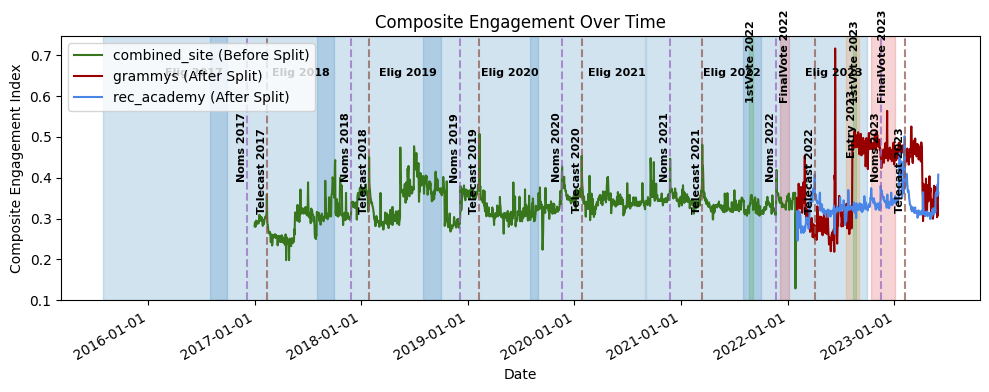

In [40]:
# Plot composite engagement index for pre-split and post-split sites
df_combined = pd.concat([combined_site, rec_academy, grammys], ignore_index=True)
result_df = compute_and_plot_composite(df_combined, show_events=True, events_df=events)

# **7.2 Composite Engagement Insights**

Look to section **4.5** for a more detailed description of each peak/plateau, as the high weight of `pages_per_session` accounts for the majority of the metric's height.

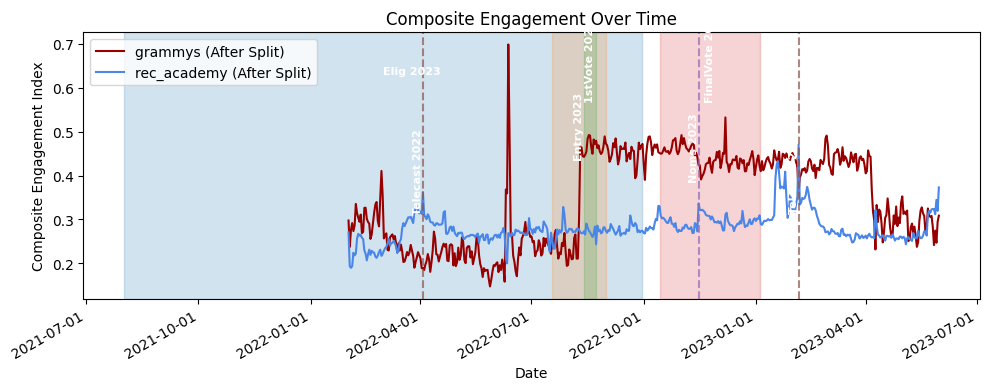

In [30]:
# Plot composite engagement index post-split
df_combined = pd.concat([rec_academy, grammys], ignore_index=True)
result_df = compute_and_plot_composite(df_combined, show_events=True, events_df=events)

### **7.2.3 Key takeaways:**  
The composite index reveals two distinct engagement drivers: one‐off spikes for rule announcements (June 2022) and multi‐month plateaus for voting windows (Aug 2022–Apr 2023). The isolated spike on RecordingAcademy.com emphasizes the value of the site split in serving discrete audience segments.

# **8. Ethics & Limitations**

In interpreting the results of our web‑analytics study, we attempt to acknowledge both ethical considerations and any constraints that may influence our findings.

### **8.1 Ethical Considerations**

**User Privacy & Consent**

All data analyzed in this project are aggregated daily metrics (e.g., sessions, pageviews, bounce counts) with no personally identifiable information.

**Data Governance**

We rely on analytics platforms operated by The Recording Academy; any changes to their data‑collection policies or retention practices during our study period (2017–2023) could affect transparency or consistency, though no significant changes could be found that might affect our findings.

### **8.2 Potential Biases**

**Demographic Aggregation**

Age distributions are reported as coarse brackets (e.g. “18–24”), and deeper demographic slices (gender, location, device type) are unavailable. We therefore cannot assess whether observed engagement differences hold uniformly across all subpopulations.

Furthermore, Grammy.com and RecordingAcademy.org do not have access to all visitors' ages, which could bias our demographic data. Given this understanding, we do not use our demographic findings in our project's final results.

### **8.3 Statistical Power & Sample Size**

**Overall Metrics**

Our power analysis indicates an ample sample size for bounce rate, session duration, and pages per session (hundreds of days, hundreds of thousands of sessions), so our primary tests are well-founded in detecting moderate effects.

Furthermore, our statistical tests confirm/deny any hypotheses made.

**Demographics**

Unfortunately, analysis of detailed demographic tests lack sufficient scopes of data to draw strong statistical inferences due to aggregation.

### **8.4 External Confounders**

**Concurrent Site Changes**

The website split on February 1, 2022 coincided with other possible interventions—site redesigns, infrastructure upgrades, or marketing campaigns that may independently influence user behavior.

**Macro Trends**

Broader factors (e.g., pandemic‑related shifts in online consumption, changes in social‑media referral traffic, or industry news cycles) are not explicitly modeled and could partially explain temporal fluctuations in engagement.

### **8.5 Data & Methodological Limitations**

**Metric Definitions**

Bounce rate and pages per session are proxy measures of engagement but do not capture qualitative elements such as content quality or user satisfaction. But for our purposes, the more a user interacts with a site, the more time the site has to engage the user or advertise upcoming events. For this reason, we choose to focus on amplifying user interaction on the site as opposed to the user's satisfaction.

**Composite Index Construction**

Our composite engagement metric uses min–max normalization and weights (0.5, 0.3, 0.2) chosen on logical grounds; different normalization methods or weight schemes could result in different index trajectories.

**Lack of Path & Cohort Analysis**

This study focuses on daily aggregates, but future work could improve our understanding by doing further analysis on outside events and how they interact with the data.

### **8.6 End of Ethics**

By transparently acknowledging these ethical and methodological boundaries, we aim to contextualize our conclusions and guide future refinements of both data collection and analytical rigor.

# **9. Conclusion**

Splitting the Recording Academy’s web presence into two dedicated domains: Grammys.com for event coverage, and RecordingAcademy.com for industry‑focused content, has significantly sharpened user engagement. After the February 1, 2022 website split, overall bounce rate fell from 41.58% to 39.86%, with RecordingAcademy.com achieving a notably low 33.67% bounce rate, while pages browsed per session rose from 1.86 to 2.28 (2.78 on RecordingAcademy.com).

Although average session duration declined (from 134.8s to 120.35s), our custom composite engagement index shows that each site now attracts its intended audience more effectively. Grammys.com drives concentrated traffic spikes around nominations and telecasts, and RecordingAcademy.com sustains elevated engagement from artists and managers during voting windows and policy announcements.

Demographically, older visitors skewed toward Grammys.com, while the Recording Academy site appealed to professionals seeking in‑depth resources, further validating our understanding of the strategic value of separation. Our demographics findings do, however, come with caveats, as explained in section 8.3.

## ***SO,* What is Our Recommendation for the Company's Website?**:

**Keep the sites separate!** We believe that this configuration optimized the depth and relevance of content delivery, ensuring fans and industry members alike encounter a personal experience that maximizes engagement and loyalty.

The finding may seem obvious, but it's always important to make sure that the statistics back your marketing decisions. Higher and lower numbers can be misleading, based on the context!

*But remember, these findings have their limits, as described in section 8*